# Calamity Risk Projection (2026–2030)

## Logic flow

1. **Weighted composite indices (AHP-informed)**  
   - **Green Index**: environmental sustainability (NDVI-based vegetation).  
   - **Hazard Index**: multi-hazard (flood, landslide, earthquake, typhoon, rainfall) with normalized weighted scoring.  
   - **Exposure**: population and infrastructure density.  
   - **Calamity Risk Likelihood**: multiplicative formula CRL = H × E × (1−G).

2. **Scenario-based future inputs (Option B – external/projected data)**  
   - Weather: monthly climate projection from historical patterns (seasonal cycle + optional trend).  
   - NDVI: seasonal pattern from historical data or trend.  
   - Population: growth projection from last known values.  
   - Earthquake/typhoon: historical monthly statistics (e.g. mean by month).  
   - Flood/landslide susceptibility and infrastructure: held at last known (static) values.

3. **LSTM time-series prediction**  
   - Use the calibrated LSTM (trained on Green Index, Hazard Index, and exposure-related parameters) to forecast **Calamity Risk Likelihood** for each barangay.  
   - Multi-step rollout: for each future month, input = last 6 months of (scenario) features; output = next month’s calamity risk; then roll the window forward using scenario inputs.

4. **Output**  
   - Projected Calamity Risk Likelihood (and optionally Green/Hazard indices from scenario) per barangay for 2026–2030 for use in the dashboard’s **projected trends** and **time slider**.

In [1]:
# Imports
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Paths
DEFAULT_BASE_PATH = Path(r"d:\Users\Vince Joseph\Downloads-New\Hazard")
BASE_PATH = DEFAULT_BASE_PATH if DEFAULT_BASE_PATH.exists() else Path.cwd()
ARTIFACTS_PATH = BASE_PATH / "model_artifacts"

# Barangays (same as training)
BARANGAYS = [
    "Baclaran",
    "Banay-Banay",
    "Banlic",
    "Barangay Dos",
    "Barangay Tres",
    "Barangay Uno",
    "Bigaa",
    "Butong",
    "Casile",
    "Diezmo",
    "Gulod",
    "Mamatid",
    "Marinig",
    "Niugan",
    "Pittland",
    "Pulo",
    "Sala",
    "San Isidro",
]

print(f"Base path: {BASE_PATH}")
print(f"Artifacts path: {ARTIFACTS_PATH}")
print(f"Barangays: {len(BARANGAYS)}")

Base path: d:\Users\Vince Joseph\Downloads-New\Hazard
Artifacts path: d:\Users\Vince Joseph\Downloads-New\Hazard\model_artifacts
Barangays: 18


In [2]:
# Load model artifacts (trained LSTM + scalers + config).
# Notes:
# - We load with compile=False because this notebook only needs inference.
# - The saved model may include legacy config keys (e.g., `quantization_config`).
#   We patch `Dense.from_config` temporarily to ignore those keys during load.

import traceback


def _patch_from_config_drop_keys(layer_cls, drop_keys):
    """Temporarily wrap `layer_cls.from_config` to drop unknown keys."""

    original = layer_cls.from_config

    @classmethod
    def from_config(cls, config):
        cfg = dict(config)  # copy
        for k in drop_keys:
            cfg.pop(k, None)
        return original(cfg)

    layer_cls.from_config = from_config
    return original


def load_lstm_model(model_path: Path):
    """Load a saved Keras model for inference only."""

    try:
        import tensorflow as tf
        from tensorflow import keras

        print(f"TensorFlow: {tf.__version__} | Keras: {keras.__version__}")
    except Exception as e:
        print("Could not import TensorFlow/Keras; skipping LSTM load.")
        print(str(e))
        return None

    model_path = Path(model_path)
    if not model_path.exists():
        print(f"Model file not found: {model_path}")
        return None

    from tensorflow import keras

    orig_dense_from_config = _patch_from_config_drop_keys(
        keras.layers.Dense, drop_keys=("quantization_config",)
    )

    try:
        return keras.models.load_model(model_path, compile=False, safe_mode=False)
    except Exception:
        print("Could not load LSTM model. Full traceback (truncated):")
        traceback.print_exc(limit=6)
        return None
    finally:
        # Always restore the original method to avoid side-effects.
        keras.layers.Dense.from_config = orig_dense_from_config


# Load model
MODEL_PATH = ARTIFACTS_PATH / "lstm_calamity_model.keras"
lstm_model = load_lstm_model(MODEL_PATH)
print("LSTM model loaded." if lstm_model is not None else "Warning: LSTM model not loaded.")

# Load scalers + config (required for Step 3+)
feature_scaler = joblib.load(ARTIFACTS_PATH / "feature_scaler.joblib")
target_scaler = joblib.load(ARTIFACTS_PATH / "target_scaler.joblib")

with open(ARTIFACTS_PATH / "model_config.json", "r") as f:
    model_config = json.load(f)

feature_cols = model_config["feature_cols"]
sequence_length = int(model_config["sequence_length"])
target_col = model_config["target_col"]

print("Scalers and config loaded.")
print(f"Sequence length: {sequence_length}")
print(f"n_features: {len(feature_cols)}")

TensorFlow: 2.20.0 | Keras: 3.13.2
LSTM model loaded.
Scalers and config loaded.
Sequence length: 6
n_features: 12


## Step 1: Load historical data and define index formulas (paper-aligned)

- Load training dataset to obtain:
  - Last 6 months of features per barangay (for LSTM seed).
  - Static per-barangay values: flood_susceptibility, landslide_susceptibility, infra_count.
- Reuse the same **normalize** and **Green / Hazard / Exposure** formulas as in the main pipeline (AHP-informed weights: hazard 50%, exposure 30%, environmental 20%).

In [3]:
# Load training data and historical sources for scenario building
training_df = pd.read_csv(BASE_PATH / 'lstm_training_data.csv')
training_df['date'] = pd.to_datetime(training_df['date'])

# Normalize to 0-100 (same as training pipeline)
def normalize(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series([50.0] * len(series), index=series.index)
    return ((series - min_val) / (max_val - min_val)) * 100

# Green Index (paper: NDVI-based)
def compute_green_index(ndvi):
    return ((ndvi + 1) / 2) * 100

# Hazard Index (paper: AHP-weighted normalized; historical bounds for consistency)
def compute_hazard_index_row(flood_sus, landslide_sus, earthquake_mag, typhoon_severity, rainfall, b):
    def n(x, lo, hi):
        if hi <= lo:
            return 50.0
        return min(100, max(0, (x - lo) / (hi - lo) * 100))
    f = n(flood_sus, 0, b['flood_max'])
    l = n(landslide_sus, 0, b['landslide_max'])
    e = n(max(earthquake_mag, 0.1), 0.1, b['eq_max'])
    t = n(max(typhoon_severity, 0.1), 0.1, b['typh_max'])
    r = n(rainfall, b['rain_min'], b['rain_max'])
    return f * 0.25 + l * 0.20 + e * 0.20 + t * 0.20 + r * 0.15

def compute_exposure_row(population, infra_count, b):
    def n(x, lo, hi):
        if hi <= lo:
            return 50.0
        return min(100, max(0, (x - lo) / (hi - lo) * 100))
    p = n(population, b['pop_min'], b['pop_max'])
    i = n(infra_count, b['infra_min'], b['infra_max'])
    return p * 0.6 + i * 0.4

# Historical bounds from training (so scenario indices match training scale)
hist = training_df
bounds = {
    'flood_max': max(hist['flood_susceptibility'].max(), 1e-6),
    'landslide_max': max(hist['landslide_susceptibility'].max(), 1e-6),
    'eq_max': max(hist['earthquake_mag'].max(), 0.1),
    'typh_max': max(hist['typhoon_severity'].max(), 0.1),
    'rain_max': hist['rainfall'].max(),
    'rain_min': hist['rainfall'].min(),
    'pop_max': max(hist['population'].max(), 1),
    'pop_min': hist['population'].min(),
    'infra_max': hist['infra_count'].max(),
    'infra_min': hist['infra_count'].min(),
}
print("Training data loaded. Date range:", training_df['date'].min(), "to", training_df['date'].max())

Training data loaded. Date range: 2020-05-01 00:00:00 to 2025-12-01 00:00:00


In [4]:
## Step 2: Build scenario-based future inputs (2026–2030, Option B)

#Use **external/historical projections**:
#-**Weather**: monthly seasonal pattern (mean temp, humidity, rainfall by month 1–12 from historical data).
#- **NDVI**: seasonal pattern from training (mean NDVI by month).
#- **Population**: extrapolate from last known (2025) with a simple growth assumption.
#- **Earthquake / typhoon**: historical monthly statistics (mean by month).
#- **Flood susceptibility, landslide susceptibility, infra_count**: last known per barangay (static).
#Then compute **green_index** and **hazard_index** for each (date, barangay) using the paper formulas.

In [5]:
# Load historical sources for Option B scenario
# Goal: make scenario inputs vary by *barangay* and over *years* (avoid flatline).

import re


def _norm_name(x: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(x).strip().lower())


# --- Weather (city-wide): seasonal mean + linear trend ---
weather_df = pd.read_csv(BASE_PATH / "weather_data.csv")
weather_df["date"] = pd.to_datetime(weather_df["date"]).dt.tz_localize(None)
weather_df["date"] = weather_df["date"].dt.to_period("M").dt.to_timestamp()
weather_df = weather_df.rename(
    columns={
        "Temperature (°C)": "temp",
        "Humidity (%)": "humidity",
        "Rainfall (mm)": "rainfall",
    }
)

weather_df["month"] = weather_df["date"].dt.month
weather_by_month = weather_df.groupby("month")[["temp", "humidity", "rainfall"]].mean()

# Linear trend per year (simple least-squares on historical monthly values)
weather_df["t_years"] = (
    (weather_df["date"] - weather_df["date"].min()).dt.days.astype(float) / 365.25
)
weather_trend_per_year = {}
for col in ["temp", "humidity", "rainfall"]:
    if weather_df[col].notna().sum() >= 2:
        weather_trend_per_year[col] = float(np.polyfit(weather_df["t_years"], weather_df[col], 1)[0])
    else:
        weather_trend_per_year[col] = 0.0


# --- Population (barangay): robust lookup + CAGR growth ---
population_df = pd.read_csv(BASE_PATH / "population_barangay.csv")
population_df["Date"] = pd.to_datetime(population_df["Date"])

pop_cols = [c for c in population_df.columns if c not in ("Date", "Total_Cabuyao")]
pop_col_map = {_norm_name(c): c for c in pop_cols}

# Precompute last known population per barangay (fallback to training if missing)
pop_last = {}
for b in BARANGAYS:
    col = pop_col_map.get(_norm_name(b))
    if col is None:
        # Fallback: last population seen in training data
        pop_last[b] = float(
            training_df[training_df["barangay"] == b].sort_values("date")["population"].iloc[-1]
        )
    else:
        pop_last[b] = float(population_df[col].dropna().iloc[-1])

# CAGR growth rate per barangay using full available range
population_df["t_years"] = (
    (population_df["Date"] - population_df["Date"].min()).dt.days.astype(float) / 365.25
)
growth_rates = {}
for b in BARANGAYS:
    col = pop_col_map.get(_norm_name(b))
    if col is None:
        growth_rates[b] = 0.0
        continue

    series = population_df[["t_years", col]].dropna()
    if len(series) < 2:
        growth_rates[b] = 0.0
        continue

    years = float(series["t_years"].iloc[-1] - series["t_years"].iloc[0])
    start = float(series[col].iloc[0])
    end = float(series[col].iloc[-1])
    if years <= 0 or start <= 0:
        growth_rates[b] = 0.0
    else:
        growth_rates[b] = (end / start) ** (1.0 / years) - 1.0

    # Guardrails (avoid explosive / negative projections)
    growth_rates[b] = float(np.clip(growth_rates[b], -0.02, 0.05))

# IMPORTANT: Align exposure normalization bounds to actual population data.
# Using `training_df['population']` can be misleading if early merged values were zeros.
# This helps prevent abrupt jumps from 2025 → 2026 due to scale mismatch.
try:
    pop_mat = population_df[pop_cols].to_numpy(dtype=float)
    pop_min = float(np.nanmin(pop_mat))
    pop_max = float(np.nanmax(pop_mat))
    if np.isfinite(pop_min) and np.isfinite(pop_max) and pop_max > pop_min:
        bounds["pop_min"] = pop_min
        bounds["pop_max"] = pop_max
except Exception:
    pass


# --- NDVI (barangay): seasonal mean + trend ---
training_df["month"] = training_df["date"].dt.month
ndvi_by_month_global = training_df.groupby("month")["ndvi"].mean()
ndvi_by_month_brgy = training_df.groupby(["barangay", "month"])["ndvi"].mean()

# NDVI trend per year per barangay from historical training data
ndvi_trend_per_year = {}
ndvi_monthly = (
    training_df.groupby(["barangay", "date"], as_index=False)["ndvi"].mean().sort_values(["barangay", "date"])
)
ndvi_monthly["t_years"] = (
    (ndvi_monthly["date"] - ndvi_monthly["date"].min()).dt.days.astype(float) / 365.25
)
for b in BARANGAYS:
    sub = ndvi_monthly[ndvi_monthly["barangay"] == b]
    if sub["ndvi"].notna().sum() >= 2:
        ndvi_trend_per_year[b] = float(np.polyfit(sub["t_years"], sub["ndvi"], 1)[0])
    else:
        ndvi_trend_per_year[b] = 0.0


# --- Earthquake / typhoon: seasonal mean (city-wide) ---
earthquake_df = pd.read_csv(BASE_PATH / "earthquake_freq.csv")
earthquake_df["date"] = pd.to_datetime(earthquake_df["date"])
earthquake_df = earthquake_df.rename(columns={"max_magnitude": "earthquake_mag"})

typhoon_df = pd.read_csv(BASE_PATH / "typhoon_freq.csv")
typhoon_df["date"] = pd.to_datetime(typhoon_df["date"])
typhoon_df = typhoon_df.rename(columns={"max_severity": "typhoon_severity"})

earthquake_df["month"] = earthquake_df["date"].dt.month
eq_by_month = earthquake_df.groupby("month")["earthquake_mag"].mean()

typhoon_df["month"] = typhoon_df["date"].dt.month
typh_by_month = typhoon_df.groupby("month")["typhoon_severity"].mean()


# --- Static values per barangay (flood, landslide, infra) ---
last_per_barangay = training_df[training_df["date"] == training_df["date"].max()].set_index("barangay")
static = {
    b: {
        "flood_susceptibility": float(last_per_barangay.loc[b, "flood_susceptibility"]),
        "landslide_susceptibility": float(last_per_barangay.loc[b, "landslide_susceptibility"]),
        "infra_count": float(last_per_barangay.loc[b, "infra_count"]),
    }
    for b in BARANGAYS
}

print("Historical sources loaded.")
print("- Weather seasonal months:", weather_by_month.shape[0])
print("- NDVI seasonal (global) months:", ndvi_by_month_global.shape[0])
print("- Population columns found:", len(pop_cols))
missing_pop_cols = [b for b in BARANGAYS if pop_col_map.get(_norm_name(b)) is None]
print("- Missing population columns for barangays:", missing_pop_cols if missing_pop_cols else "None")

Historical sources loaded.
- Weather seasonal months: 12
- NDVI seasonal (global) months: 12
- Population columns found: 18
- Missing population columns for barangays: None


In [6]:
# Build future_df: one row per (date, barangay) for 2026-01 to 2030-12
# - Weather: seasonal + trend (with scenario amplifiers for sensitivity)
# - NDVI: barangay seasonal + barangay trend (with optional decline drift)
# - Population: barangay CAGR growth (with optional growth multiplier/cap)
#
# NOTE: These scenario knobs are meant to produce clearer differences across 2026–2030
# for projection sensitivity testing. Keep them conservative if you want minimal deviation.

# --- Scenario knobs (tune as needed) ---
SCENARIO_RAIN_LEVEL_MULT = 1.10          # overall wetter baseline (e.g., +10%)
SCENARIO_RAIN_TREND_MULT = 2.00          # amplify historical rainfall trend
SCENARIO_TYPHOON_LEVEL_MULT = 1.15       # stronger typhoon severity baseline
SCENARIO_TYPHOON_GROWTH_PER_YEAR = 0.03  # additional increase per year
SCENARIO_EQ_LEVEL_MULT = 1.05            # slightly higher earthquake magnitude baseline

SCENARIO_POP_GROWTH_MULT = 1.50          # multiply CAGR growth rates
SCENARIO_POP_GROWTH_CAP = 0.08           # cap effective growth rate (8%/yr)

SCENARIO_NDVI_DRIFT_PER_YEAR = -0.010    # gradual vegetation decline (-0.01 NDVI / year)


future_months = pd.date_range("2026-01-01", "2030-12-01", freq="MS")
rows = []

# Reference point for trends (years since end of 2025)
trend_ref = pd.Timestamp("2025-12-01")

for date in future_months:
    month = int(date.month)
    months_ahead = (date.year - 2025) * 12 + (date.month - 12)
    years_ahead = max(0, months_ahead) / 12.0

    # Seasonal values (city-wide) + trend (with scenario multipliers)
    # Use a ramp so 2026 starts close to 2025, then gradually intensifies toward 2030.
    w = weather_by_month.loc[month]
    temp_val = float(w["temp"] + weather_trend_per_year.get("temp", 0.0) * years_ahead)
    hum_val = float(w["humidity"] + weather_trend_per_year.get("humidity", 0.0) * years_ahead)

    ramp = float(np.clip(years_ahead / 5.0, 0.0, 1.0))  # 0 in 2026 → 1 by ~2030

    rain_level_mult = 1.0 + (SCENARIO_RAIN_LEVEL_MULT - 1.0) * ramp
    rain_trend_mult = 1.0 + (SCENARIO_RAIN_TREND_MULT - 1.0) * ramp
    base_rain = float(w["rainfall"]) * rain_level_mult
    rain_trend = float(weather_trend_per_year.get("rainfall", 0.0) * rain_trend_mult * years_ahead)
    rain_val = float(base_rain + rain_trend)

    # Seasonal values from historical (use .get for months with no earthquake/typhoon data)
    eq_level_mult = 1.0 + (SCENARIO_EQ_LEVEL_MULT - 1.0) * ramp
    eq_val = float(eq_by_month.get(month, 0.0)) * eq_level_mult

    typh_level_mult = 1.0 + (SCENARIO_TYPHOON_LEVEL_MULT - 1.0) * ramp
    typh_val = float(typh_by_month.get(month, 0.0)) * typh_level_mult
    typh_val = float(typh_val * (1.0 + (SCENARIO_TYPHOON_GROWTH_PER_YEAR * ramp) * years_ahead))

    for barangay in BARANGAYS:
        st = static[barangay]

        # Population: project with growth (CAGR) + scenario multiplier
        base_pop = float(pop_last.get(barangay, 0.0))
        g = float(growth_rates.get(barangay, 0.0))
        g_eff = float(np.clip(g * SCENARIO_POP_GROWTH_MULT, -0.02, SCENARIO_POP_GROWTH_CAP))
        pop_val = float(base_pop * ((1.0 + g_eff) ** years_ahead))

        # NDVI: barangay seasonal + barangay trend + optional drift
        ndvi_seasonal = ndvi_by_month_brgy.get((barangay, month), ndvi_by_month_global.loc[month])
        ndvi_val = float(
            float(ndvi_seasonal)
            + float(ndvi_trend_per_year.get(barangay, 0.0)) * years_ahead
            + float(SCENARIO_NDVI_DRIFT_PER_YEAR) * years_ahead
        )
        ndvi_val = float(np.clip(ndvi_val, -1.0, 1.0))

        hazard_val = float(
            compute_hazard_index_row(
                st["flood_susceptibility"],
                st["landslide_susceptibility"],
                eq_val,
                typh_val,
                rain_val,
                bounds,
            )
        )
        green_val = float(compute_green_index(ndvi_val))

        rows.append(
            {
                "date": date,
                "barangay": barangay,
                "temp": temp_val,
                "humidity": hum_val,
                "rainfall": rain_val,
                "population": pop_val,
                "flood_susceptibility": st["flood_susceptibility"],
                "landslide_susceptibility": st["landslide_susceptibility"],
                "ndvi": ndvi_val,
                "earthquake_mag": eq_val,
                "typhoon_severity": typh_val,
                "infra_count": st["infra_count"],
                "green_index": green_val,
                "hazard_index": hazard_val,
            }
        )

future_df = pd.DataFrame(rows)

# Sanity checks (avoid silent flatlines / missing barangays)
assert future_df.shape[0] == len(future_months) * len(BARANGAYS)
assert set(future_df["barangay"].unique()) == set(BARANGAYS)

print(
    f"Future scenario built: {future_df.shape[0]} rows ({len(future_months)} months x {len(BARANGAYS)} barangays)"
)
print(f"Date range: {future_df['date'].min().date()} to {future_df['date'].max().date()}")

# Show variation diagnostics (per barangay std across time)
diag = (
    future_df.groupby("barangay")[["population", "ndvi", "green_index", "hazard_index"]]
    .std(numeric_only=True)
    .sort_index()
)
print("\nScenario std-dev by barangay (should be > 0 for non-flat inputs):")
print(diag.round(6).head(6))

future_df.head(3)

Future scenario built: 1080 rows (60 months x 18 barangays)
Date range: 2026-01-01 to 2030-12-01

Scenario std-dev by barangay (should be > 0 for non-flat inputs):
               population      ndvi  green_index  hazard_index
barangay                                                      
Baclaran       105.559523  0.021901     1.095049      3.678593
Banay-Banay    628.900076  0.021901     1.095049      3.678593
Banlic          50.447719  0.021901     1.095049      3.678593
Barangay Dos   552.764102  0.021901     1.095049      3.678593
Barangay Tres   48.866952  0.021901     1.095049      3.678593
Barangay Uno   636.485441  0.021901     1.095049      3.678593


,date,barangay,temp,humidity,rainfall,population,flood_susceptibility,landslide_susceptibility,ndvi,earthquake_mag,typhoon_severity,infra_count,green_index,hazard_index
0,2026-01-01,Baclaran,25.490511,79.242684,61.741446,14318.877801,1.5625,2.087027,0.224939,1.451208,0.0,2.0,61.246958,33.384452
1,2026-01-01,Banay-Banay,25.490511,79.242684,61.741446,22471.136653,0.0000,2.421197,0.224939,1.451208,0.0,5.0,61.246958,34.551762
2,2026-01-01,Banlic,25.490511,79.242684,61.741446,20511.099098,0.0000,2.600856,0.224939,1.451208,0.0,9.0,61.246958,35.505294


## Step 3: Last 6 months of features per barangay (LSTM seed)

Take the last 6 months of the training data (2025-07 to 2025-12), scale with the same `feature_scaler`, and store one window per barangay for the forecasting loop.

In [7]:
# Last N months of training data (seed window for forecasting)
cutoff = training_df["date"].max() - pd.DateOffset(months=sequence_length)
last_n = training_df[training_df["date"] > cutoff].sort_values(["barangay", "date"])

# Expect exactly N unique months overall
assert last_n["date"].nunique() == sequence_length, f"Need exactly {sequence_length} months"

# Scale with the same scaler used in training
last_n_scaled = last_n.copy()
last_n_scaled[feature_cols] = feature_scaler.transform(last_n[feature_cols])

# One (sequence_length, n_features) window per barangay
last_6_scaled: dict[str, np.ndarray] = {}

# Fallback row if a barangay is missing completely (use global mean of scaled features)
_global_scaled_mean_row = last_n_scaled[feature_cols].mean(axis=0).values.astype(np.float32)

for b in BARANGAYS:
    brgy_data = last_n_scaled[last_n_scaled["barangay"] == b][feature_cols].values.astype(np.float32)

    if brgy_data.shape[0] >= sequence_length:
        window = brgy_data[-sequence_length:, :]
    elif brgy_data.shape[0] > 0:
        # Pad by repeating last available row
        pad = np.repeat(brgy_data[-1:, :], sequence_length - brgy_data.shape[0], axis=0)
        window = np.vstack([brgy_data, pad])
    else:
        # If this ever happens, fill with a reasonable default to avoid crashes
        window = np.repeat(_global_scaled_mean_row.reshape(1, -1), sequence_length, axis=0)

    last_6_scaled[b] = window

print(
    f"Seed windows prepared for {len(last_6_scaled)} barangays. Shape per barangay: {next(iter(last_6_scaled.values())).shape}"
)

Seed windows prepared for 18 barangays. Shape per barangay: (6, 12)


## Step 4: 2026–2030 forecasting loop

For each barangay: start with the last 6 months’ scaled features; for each future month (2026-01 … 2030-12), run the LSTM (input shape `(1, 6, 12)`), inverse-transform the predicted calamity risk, then roll the window by appending the **scenario** row for that month (scaled) and dropping the oldest.

In [8]:
# Multi-step projection: one step per month, roll window with scenario

# Fast lookup for scenario rows
future_lookup = future_df.set_index(["barangay", "date"])


def formula_risk_from_row(row) -> float:
    """Multiplicative formula risk in [0, 1]: CRL = H × E × (1−G)."""
    H = float(row["hazard_index"]) / 100.0
    E = float(compute_exposure_row(float(row["population"]), float(row["infra_count"]), bounds)) / 100.0
    G = float(row["green_index"]) / 100.0
    cr = H * E * (1.0 - G)
    return float(np.clip(cr, 0.0, 1.0))


# Projection mode:
# - "lstm": use LSTM only (can flatline)
# - "formula": use formula only
# - "hybrid": blend LSTM with formula to avoid flatline
#
# Tip:
# - If you want stronger year-to-year differences, keep "hybrid" and use a LOWER alpha
#   (more formula/scenario influence), or test "lstm" to inspect pure model behavior.
PROJECTION_MODE = "hybrid"

# Blend weight for hybrid (0 = pure formula, 1 = pure LSTM)
HYBRID_ALPHA = 0.20

if lstm_model is None:
    PROJECTION_MODE = "formula"


results = []

for barangay in BARANGAYS:
    window = last_6_scaled[barangay].copy()

    for date in future_months:
        scenario_row_series = future_lookup.loc[(barangay, date)]
        cr_formula = formula_risk_from_row(scenario_row_series)

        cr_lstm = None
        if PROJECTION_MODE in ("lstm", "hybrid"):
            X_batch = window.reshape(1, sequence_length, len(feature_cols))
            y_scaled = lstm_model.predict(X_batch, verbose=0)
            cr_lstm = float(target_scaler.inverse_transform(y_scaled)[0, 0])
            cr_lstm = float(np.clip(cr_lstm, 0.0, 1.0))

        if PROJECTION_MODE == "formula":
            cr_final = cr_formula
        elif PROJECTION_MODE == "lstm":
            cr_final = cr_lstm
        else:
            # Hybrid blend (stable + non-flat)
            cr_final = float(HYBRID_ALPHA * cr_lstm + (1.0 - HYBRID_ALPHA) * cr_formula)

        results.append(
            {
                "barangay": barangay,
                "date": date,
                # Keep single column used by later cells
                "calamity_risk_likelihood": cr_final,
                # Extra debug columns (help diagnose flatlines)
                "calamity_risk_lstm": cr_lstm,
                "calamity_risk_formula": cr_formula,
            }
        )

        # Roll: next row from scenario (scaled features)
        scenario_features = scenario_row_series[feature_cols].to_numpy(dtype=float).reshape(1, -1)
        new_row = feature_scaler.transform(scenario_features)
        window = np.vstack([window[1:], new_row]).astype(np.float32)

forecast_df = pd.DataFrame(results)

print(f"Projection done. Rows: {len(forecast_df)} | mode={PROJECTION_MODE} | alpha={HYBRID_ALPHA}")

# Quick check: verify outputs are not flat
out_std = forecast_df.groupby("barangay")["calamity_risk_likelihood"].std().sort_values(ascending=False)
print("Top 5 barangays by output std-dev:")
print(out_std.head(5).round(6))
print("Bottom 5 barangays by output std-dev:")
print(out_std.tail(5).round(6))

forecast_df.head(5)

Projection done. Rows: 1080 | mode=hybrid | alpha=0.2
Top 5 barangays by output std-dev:
barangay
Sala            0.031810
Casile          0.027583
Diezmo          0.027532
Barangay Uno    0.023009
Pulo            0.022560
Name: calamity_risk_likelihood, dtype: float64
Bottom 5 barangays by output std-dev:
barangay
Banlic          0.015981
Marinig         0.015740
Niugan          0.015617
Butong          0.015168
Barangay Dos    0.014405
Name: calamity_risk_likelihood, dtype: float64


,barangay,date,calamity_risk_likelihood,calamity_risk_lstm,calamity_risk_formula
0,Baclaran,2026-01-01,0.297893,0.323310,0.291538
1,Baclaran,2026-02-01,0.311744,0.396497,0.290556
2,Baclaran,2026-03-01,0.327942,0.482210,0.289375
3,Baclaran,2026-04-01,0.341539,0.545272,0.290606
4,Baclaran,2026-05-01,0.369295,0.593600,0.313219


In [9]:
# --- Export forecast_df to a yearly JSON for the slider map ---
# This file matches the structure expected by `calamity_risk_server.py`:
#   { "2020": { "Barangay": {...} }, ... }
#
# We combine:
# - Historical years (2020–2025) from `training_df`
# - Projected years (2026–2030) from `forecast_df` merged with `future_df` scenario inputs

import json


def classify_crl(raw_0_1: float) -> str:
    if raw_0_1 < 0.20:
        return "Very Low"
    if raw_0_1 < 0.40:
        return "Low"
    if raw_0_1 < 0.60:
        return "Moderate"
    if raw_0_1 < 0.80:
        return "High"
    return "Very High"


# Historical (yearly mean per barangay)
hist_df = training_df.copy()
hist_df["year"] = hist_df["date"].dt.year
hist_yearly = (
    hist_df.groupby(["year", "barangay"], as_index=False)
    .agg(
        {
            "calamity_risk_likelihood": "mean",
            "hazard_index": "mean",
            "green_index": "mean",
            "population": "mean",
            "infra_count": "mean",
        }
    )
)

# Future (merge LSTM/hybrid outputs with scenario indices, then yearly mean)
proj_df = forecast_df.copy()
proj_df = proj_df.merge(
    future_df[["date", "barangay", "hazard_index", "green_index", "population", "infra_count"]],
    on=["date", "barangay"],
    how="left",
)
proj_df["year"] = proj_df["date"].dt.year

proj_yearly = (
    proj_df.groupby(["year", "barangay"], as_index=False)
    .agg(
        {
            "calamity_risk_likelihood": "mean",
            "hazard_index": "mean",
            "green_index": "mean",
            "population": "mean",
            "infra_count": "mean",
        }
    )
)

combined_yearly = pd.concat([hist_yearly, proj_yearly], ignore_index=True)

# Build JSON structure
out = {}
for _, row in combined_yearly.iterrows():
    year = str(int(row["year"]))
    brgy = str(row["barangay"])

    cr_raw = float(np.clip(row["calamity_risk_likelihood"], 0.0, 1.0))
    hazard_idx = float(np.clip(row["hazard_index"], 0.0, 100.0))
    green_idx = float(np.clip(row["green_index"], 0.0, 100.0))

    # Exposure component in 0–1 (same function used elsewhere in notebook)
    expo_0_100 = float(
        compute_exposure_row(float(row["population"]), float(row["infra_count"]), bounds)
    )
    expo_raw = float(np.clip(expo_0_100 / 100.0, 0.0, 1.0))

    out.setdefault(year, {})[brgy] = {
        "calamity_risk": round(cr_raw * 100.0, 2),
        "calamity_risk_raw": round(cr_raw, 4),
        "risk_class": classify_crl(cr_raw),
        "hazard_index": round(hazard_idx, 2),
        "hazard_index_raw": round(hazard_idx / 100.0, 4),
        "green_index": round(green_idx, 2),
        "green_index_raw": round(green_idx / 100.0, 4),
        "exposure_norm": round(expo_raw, 4),
    }

# Sort years for readability
out_sorted = {k: out[k] for k in sorted(out.keys(), key=lambda x: int(x))}

OUTPUT_JSON = BASE_PATH / "calamity_risk_forecast_data.json"
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(out_sorted, f, indent=2)

print(f"Saved forecast map JSON: {OUTPUT_JSON}")
print(f"Years: {min(map(int, out_sorted.keys()))}–{max(map(int, out_sorted.keys()))}")
print(f"Barangays (sample): {list(next(iter(out_sorted.values())).keys())[:5]}")


Saved forecast map JSON: d:\Users\Vince Joseph\Downloads-New\Hazard\calamity_risk_forecast_data.json
Years: 2020–2030
Barangays (sample): ['Baclaran', 'Banay-Banay', 'Banlic', 'Barangay Dos', 'Barangay Tres']


## Step 5: Save and plot projection results

Save the projected Calamity Risk Likelihood to CSV for use in the dashboard (e.g. time slider, projected trends). Optionally plot a sample of barangays over 2026–2030.

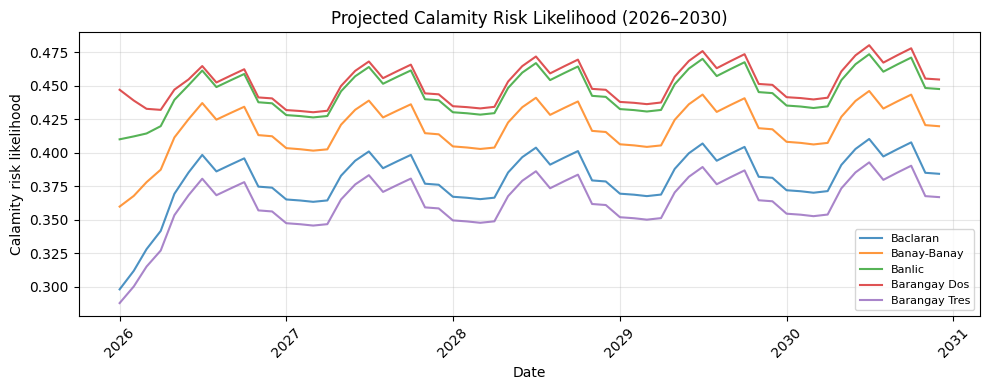

In [10]:
# Plot: projected calamity risk for a few barangays over 2026-2030
import matplotlib.pyplot as plt

plot_barangays = BARANGAYS[:5]  # first 5
fig, ax = plt.subplots(figsize=(10, 4))
for b in plot_barangays:
    sub = forecast_df[forecast_df['barangay'] == b].sort_values('date')
    ax.plot(sub['date'], sub['calamity_risk_likelihood'], label=b, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Calamity risk likelihood')
ax.set_title('Projected Calamity Risk Likelihood (2026–2030)')
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Summary: mean calamity risk by year (2026-2030) per barangay
forecast_df["year"] = forecast_df["date"].dt.year

summary = forecast_df.groupby(["barangay", "year"])["calamity_risk_likelihood"].mean().unstack("year")
print("Mean calamity risk likelihood by year (columns) and barangay (rows):")
print(summary.round(6))

# Show change from 2026 to 2030 (helps detect flatlines)
if 2026 in summary.columns and 2030 in summary.columns:
    delta = (summary[2030] - summary[2026]).sort_values()
    print("\nDelta (2030 - 2026) by barangay:")
    print(delta.round(6))

# Report within-year variability (monthly std per year)
std_by_year = forecast_df.groupby(["barangay", "year"])["calamity_risk_likelihood"].std().unstack("year")
print("\nWithin-year monthly std-dev (higher = less flat within the year):")
print(std_by_year.round(6))


Mean calamity risk likelihood by year (columns) and barangay (rows):
year               2026      2027      2028      2029      2030
barangay                                                       
Baclaran       0.362782  0.380668  0.383105  0.385811  0.388783
Banay-Banay    0.406711  0.418696  0.420399  0.422387  0.424659
Banlic         0.437033  0.443766  0.446281  0.449062  0.452110
Barangay Dos   0.447654  0.447854  0.451176  0.454819  0.458788
Barangay Tres  0.347016  0.362948  0.365458  0.368236  0.371290
Barangay Uno   0.337772  0.357611  0.361044  0.364808  0.368906
Bigaa          0.374715  0.388896  0.391031  0.393442  0.396129
Butong         0.432022  0.435310  0.437712  0.440381  0.443318
Casile         0.300869  0.328766  0.332214  0.335995  0.340112
Diezmo         0.296020  0.324121  0.326616  0.329378  0.332408
Gulod          0.418450  0.432992  0.439556  0.446685  0.454402
Mamatid        0.464414  0.476190  0.476638  0.477395  0.478461
Marinig        0.544949  0.550242  